# BTC Hourly — Hybrydowy model z DQN (v2)

## Architektura dwufazowa

```
┌─────────────────────────────────────────────────────────┐
│  FAZA 1 — Klasyfikator kierunku ceny                   │
│                                                         │
│  Feature Selection (Pearson p<0.05)                    │
│  + WMA-30d jako dodatkowe cechy                         │
│                                                         │
│  Dane (72h okno) ──► LSTM + Attention ──► z_t (64d)   │
│                              │                          │
│                              └──► XGBoostClassifier    │
│                                    │                    │
│                                    ▼                    │
│                          pred_proba_up (0-1)            │
└───────────────────────────┬─────────────────────────── ┘
                            │
                            ▼
┌─────────────────────────────────────────────────────────┐
│  FAZA 2 — Agent tradingowy (DQN)                       │
│                                                         │
│  Stan: [z_t ‖ pred_proba_up ‖ position_t]             │
│                    │                                    │
│              Q-Network (MLP)                            │
│          128 → 128 → 64 → 3 akcje                      │
│                    │                                    │
│         ┌──────────┼──────────┐                        │
│       FLAT        LONG      SHORT                      │
│                                                         │
│  Nagroda: position × log_return_1h                     │
│         − TC × |Δposition|                             │
│                                                         │
│  Trening: Experience Replay                             │
│         + Target Network                                │
│         + ε-greedy                                      │
└─────────────────────────────────────────────────────────┘
```

### Zmiany względem v1
- **Target LSTM**: regresja zwrotu → **klasyfikacja kierunku (góra/dół)** — eliminuje mean collapse
- **Feature selection**: Pearson correlation, tylko cechy istotne statystycznie (p < 0.05)
- **WMA-30d**: ważona średnia ruchoma jako dodatkowe cechy (za Mallqui & Fernandes 2018)
- **LSTM + Attention pooling**: `K_HIDDEN=64`, `recurrent_dropout=0.1`, attention zamiast ostatniego stanu
- **XGBoostClassifier** zamiast XGBRegressor

## 1. Importy i konfiguracja

In [68]:
import os, warnings, io, re, random
from collections import deque
from scipy.stats import pearsonr

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, LayerNormalization, Softmax, Lambda
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import xgboost as xgb

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

plt.rcParams.update({
    'figure.figsize': (14, 6), 'figure.dpi': 100,
    'axes.titlesize': 13, 'axes.labelsize': 11, 'legend.fontsize': 10,
})

COLOR_TRUE   = '#111111'
COLOR_LSTM   = '#1565C0'
COLOR_HYBRID = '#C62828'
COLOR_NAIVE  = '#9E9E9E'
COLOR_DQN    = '#6A1B9A'
COLOR_BH     = '#F57C00'

OUT_DIR = './data/hourly/processed'
os.makedirs(OUT_DIR, exist_ok=True)

print('Biblioteki wczytane.')
print(f'TF: {tf.__version__}   XGB: {xgb.__version__}')

Biblioteki wczytane.
TF: 2.16.2   XGB: 3.2.0


## 2. Wczytanie danych i cel: kierunek ceny za 72h (klasyfikacja binarna)

**Target:** `1` jeśli `Close[t+72] > Close[t]`, inaczej `0`.

Zmiana z regresji zwrotu na klasyfikację kierunku — podejście za Mallqui & Fernandes (2018).
Eliminuje mean collapse: model nie może "uciec" do przewidywania zera.

In [69]:
HORIZON      = 24     # 3 doby
WMA_WINDOW   = 30 * 24  # 30 dni w godzinach

CSV_PATH = '/Users/mateuszpuk/Desktop/bitcoin-onchain-analysis/src/hourly/data/hourly/processed/bitcoin_hourly_final.csv'

df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').set_index('timestamp')
df = df.interpolate(method='linear', limit_direction='forward').ffill().dropna()

# Target binarny: 1 = cena wzrośnie za HORIZON godzin, 0 = spadnie
df['target_dir'] = (df['Close'].shift(-HORIZON) > df['Close']).astype(int)

# Zachowaj też ciągły zwrot — potrzebny do nagrody DQN i diagnostyki
df['target_return_7d_fwd'] = np.log(df['Close'].shift(-HORIZON) / df['Close'])
df['log_return_1h'] = np.log(df['Close'] / df['Close'].shift(1))

df = df.dropna(subset=['target_dir', 'target_return_7d_fwd', 'log_return_1h'])

print(f'Zakres dat:      {df.index.min()} → {df.index.max()}')
print(f'Liczba rekordów: {len(df):,}')
print(f'Balans klas: UP={df["target_dir"].mean():.1%}  DOWN={(1-df["target_dir"].mean()):.1%}')

Zakres dat:      2022-05-10 01:00:00 → 2026-08-26 22:00:00
Liczba rekordów: 36,131
Balans klas: UP=51.5%  DOWN=48.5%


## 3. Cechy wejściowe + WMA-30d + selekcja Pearson

**Krok 1:** Zbuduj bazowe cechy + ich 30-dniowe WMA (Mallqui & Fernandes 2018, sekcja 3.2).

**Krok 2:** Selekcja przez korelację Pearsona z targetem — tylko cechy istotne statystycznie (p < 0.05).

In [70]:
# Zredukowana, stabilna lista cech bez WMA
FEATURE_COLS = [
    'log_return_1h',
    'log_return_24h',
    'rsi_14h',
    'macd_hist',
    'bollinger_bandwidth',
    'dist_sma_168h',
    'whale_tx_count_zscore_168h'
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f"Wybrano {len(FEATURE_COLS)} kluczowych cech.")

Wybrano 6 kluczowych cech.


In [71]:
# ── Selekcja przez korelację Pearsona ─────────────────────────────────────────
# Używamy tylko danych treningowych do selekcji (brak wycieku)
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10
n = len(df)
n_train = int(n * TRAIN_FRAC)
n_val   = int(n * VAL_FRAC)

_train_sel = df.iloc[:n_train]

print(f'{"Cecha":<40}  {"r":>8}  {"p":>8}  {"istotna"}')
print('-' * 70)



print(FEATURE_COLS)


Cecha                                            r         p  istotna
----------------------------------------------------------------------
['log_return_1h', 'log_return_24h', 'rsi_14h', 'macd_hist', 'bollinger_bandwidth', 'whale_tx_count_zscore_168h']


## 4. Podział chronologiczny 80 / 10 / 10

In [72]:
train_df = df.iloc[:n_train - HORIZON]
val_df   = df.iloc[n_train : n_train + n_val - HORIZON]
test_df  = df.iloc[n_train + n_val:]

print(f'Trening:   {len(train_df):>7,} h  ({train_df.index.min()} → {train_df.index.max()})')
print(f'Walidacja: {len(val_df):>7,} h  ({val_df.index.min()} → {val_df.index.max()})')
print(f'Test:      {len(test_df):>7,} h  ({test_df.index.min()} → {test_df.index.max()})')
print()
print(f'Balans klas trening: UP={train_df[TARGET_COL].mean():.1%}')
print(f'Balans klas trening: UP={val_df[TARGET_COL].mean():.1%}')
print(f'Balans klas test:    UP={test_df[TARGET_COL].mean():.1%}')

Trening:    28,880 h  (2022-05-10 01:00:00 → 2025-09-17 16:00:00)
Walidacja:   3,589 h  (2025-09-18 18:00:00 → 2026-02-24 18:00:00)
Test:        3,614 h  (2026-02-25 20:00:00 → 2026-08-26 22:00:00)

Balans klas trening: UP=51.8%
Balans klas trening: UP=46.9%
Balans klas test:    UP=54.3%


## 5. Skalowanie i sekwencje LSTM (okno 72 h)

In [73]:
WINDOW_LSTM = 72

scaler_X = StandardScaler()

X_train_raw = scaler_X.fit_transform(train_df[FEATURE_COLS].values)
X_val_raw   = scaler_X.transform(val_df[FEATURE_COLS].values)
X_test_raw  = scaler_X.transform(test_df[FEATURE_COLS].values)

# Target binarny — bez skalowania
y_train_raw = train_df[TARGET_COL].values.astype(np.float32)
y_val_raw   = val_df[TARGET_COL].values.astype(np.float32)
y_test_raw  = test_df[TARGET_COL].values.astype(np.float32)

def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i, :])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_tr, y_tr = make_sequences(X_train_raw, y_train_raw, WINDOW_LSTM)
X_va, y_va = make_sequences(X_val_raw,   y_val_raw,   WINDOW_LSTM)
X_te, y_te = make_sequences(X_test_raw,  y_test_raw,  WINDOW_LSTM)

n_features = X_tr.shape[-1]
print(f'Sekwencje: train={X_tr.shape}  val={X_va.shape}  test={X_te.shape}')
print(f'Balans klas (train seq): UP={y_tr.mean():.1%}')

# Pomocnicze tablice (indeksy po WINDOW_LSTM)
train_last_close = train_df['Close'].values[WINDOW_LSTM:]
val_last_close   = val_df['Close'].values[WINDOW_LSTM:]
test_last_close  = test_df['Close'].values[WINDOW_LSTM:]

test_return_full_true = test_df['target_return_7d_fwd'].values[WINDOW_LSTM:]
hourly_train = train_df['log_return_1h'].values[WINDOW_LSTM:]
hourly_val   = val_df['log_return_1h'].values[WINDOW_LSTM:]
hourly_test  = test_df['log_return_1h'].values[WINDOW_LSTM:]

Sekwencje: train=(28808, 72, 6)  val=(3517, 72, 6)  test=(3542, 72, 6)
Balans klas (train seq): UP=51.8%


## 6. Faza 1 — LSTM z Attention (klasyfikator kierunku)

### Zmiany względem v1
- **Target**: sigmoid + binary_crossentropy (nie Huber regresja)
- **K_HIDDEN=64** (było 16)
- **recurrent_dropout=0.1**
- **Attention pooling** zamiast ostatniego hidden state
- Mniejsza regularyzacja l2 (1e-5 zamiast 5e-4)

In [74]:
def print_polish_summary(model):
    stream = io.StringIO()
    model.summary(print_fn=lambda x: stream.write(x + '\n'))
    s = stream.getvalue()
    names = {'dense': 'Gęsta', 'dropout': 'Dropout', 'lstm': 'LSTM',
             'inputlayer': 'Wejście', 'layernormalization': 'Norm. warstw',
             'softmax': 'Softmax', 'lambda': 'Lambda'}
    def shorten(m):
        t = m.group(2).lower()
        return f'{names.get(t, m.group(2)):<{len(m.group(0))}}'
    s = re.sub(r'(\w+)\s*\((\w+)\)', shorten, s)
    for eng, pol in {
        "type         ": "Warstwa (typ)", "Output Shape   ": "Kształt wyjścia",
        "  Param #": "Parametry", "Total params:": "Suma parametrów:        ",
        "Trainable params:": "Parametry trenowalne:   ",
        "Non-trainable params:": "Parametry nie-trenowalne:",
    }.items():
        s = s.replace(eng, pol)
    print(s)

In [75]:
tf.keras.backend.clear_session()

from sklearn.utils.class_weight import compute_class_weight

# ── 1. Obliczenie wag klas dla zrównoważenia biasu ────────────────────────────
classes = np.unique(y_tr)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Wagi klas (0=DOWN, 1=UP): {class_weight_dict}")

# ── 2. Kompilacja i trening LSTM ──────────────────────────────────────────────
tf.keras.backend.clear_session()
K_HIDDEN = 64

inputs = Input(shape=(WINDOW_LSTM, n_features), name='input_layer')
lstm1 = LSTM(K_HIDDEN, return_sequences=True, recurrent_dropout=0.1,
             kernel_regularizer=l2(1e-5), name='lstm_layer_1')(inputs)
norm1 = LayerNormalization()(lstm1)

# Attention pooling
seq_out    = norm1
attn_score = Dense(1, activation='tanh')(seq_out)
attn_w     = Softmax(axis=1)(attn_score)
lstm_out   = Lambda(lambda x: tf.reduce_sum(x[0] * x[1], axis=1), name='attention_pooling')([seq_out, attn_w])

norm2    = LayerNormalization()(lstm_out)
drop     = Dropout(0.2)(norm2)
dir_head = Dense(1, activation='sigmoid', name='dir_head')(drop)

lstm_model        = Model(inputs=inputs, outputs=dir_head)
feature_extractor = Model(inputs=inputs, outputs=lstm_out)
print_polish_summary(lstm_model)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)
lstm_model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

cb = [
    EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, min_lr=1e-6, mode='max', verbose=1)
]

print("Trenowanie LSTM z wagami klas...")
hist = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=120,
    batch_size=128,
    class_weight=class_weight_dict,   # <-- Kluczowa zmiana
    callbacks=cb,
    verbose=1,
    shuffle=True
)
print("✓ LSTM wytrenowany.")

Wagi klas (0=DOWN, 1=UP): {0: 1.0373784659704717, 1: 0.965221470213764}


Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Warstwa (typ)       ┃ Kształt wyjścia   ┃  Parametry ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 72, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM                │ (None, 72, 64)    │     18,176 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 72, 64)    │        128 │ lstm_layer_1[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Gęsta               │ (None, 72, 1)     │         65 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼

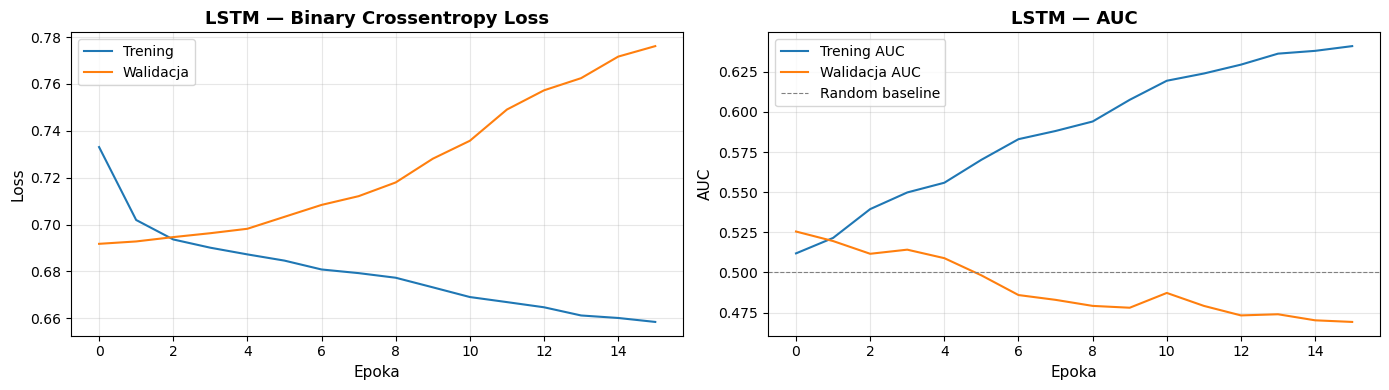

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(hist.history['loss'],     label='Trening')
ax.plot(hist.history['val_loss'], label='Walidacja')
ax.set_title('LSTM — Binary Crossentropy Loss', fontweight='bold')
ax.set_xlabel('Epoka'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(hist.history['auc'],     label='Trening AUC')
ax.plot(hist.history['val_auc'], label='Walidacja AUC')
ax.axhline(0.5, color='gray', ls='--', lw=0.8, label='Random baseline')
ax.set_title('LSTM — AUC', fontweight='bold')
ax.set_xlabel('Epoka'); ax.set_ylabel('AUC')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'p1_lstm_learning_curve.png'), bbox_inches='tight', dpi=130)
plt.show()

## 7. Diagnostyka LSTM — histogram predykcji

Po zmianie na klasyfikację histogram `pred_proba_up` powinien być **rozłożony po całym przedziale [0,1]**, nie skupiony w jednym punkcie.

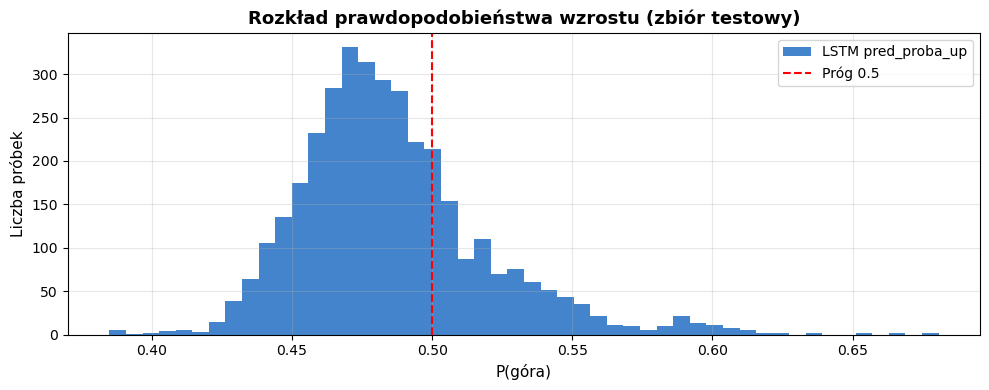

LSTM — Test Accuracy: 50.0%   AUC: 0.5594
              precision    recall  f1-score   support

        DOWN       0.47      0.76      0.58      1607
          UP       0.59      0.29      0.38      1935

    accuracy                           0.50      3542
   macro avg       0.53      0.52      0.48      3542
weighted avg       0.53      0.50      0.47      3542



In [77]:
pred_proba_te = lstm_model.predict(X_te, verbose=0).flatten()
pred_class_te = (pred_proba_te > 0.5).astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pred_proba_te, bins=50, alpha=0.8, color=COLOR_LSTM, label='LSTM pred_proba_up')
ax.axvline(0.5, color='red', ls='--', lw=1.5, label='Próg 0.5')
ax.set_title('Rozkład prawdopodobieństwa wzrostu (zbiór testowy)', fontweight='bold')
ax.set_xlabel('P(góra)'); ax.set_ylabel('Liczba próbek')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Metryki LSTM
acc  = accuracy_score(y_te, pred_class_te)
auc  = roc_auc_score(y_te, pred_proba_te)
print(f'LSTM — Test Accuracy: {acc:.1%}   AUC: {auc:.4f}')
print(classification_report(y_te, pred_class_te, target_names=['DOWN', 'UP']))

## 8. Ekstrakcja wektora z (hidden state z Attention)

In [78]:
z_train = feature_extractor.predict(X_tr, verbose=0)
z_val   = feature_extractor.predict(X_va, verbose=0)
z_test  = feature_extractor.predict(X_te, verbose=0)

print(f'Wektory z: train={z_train.shape}  val={z_val.shape}  test={z_test.shape}')

Wektory z: train=(28808, 64)  val=(3517, 64)  test=(3542, 64)


## 9. Faza 1 cd. — XGBoostClassifier

XGBoost jako klasyfikator na wektorach z_t. Nie dodajemy `last_close` — absolutna cena nie generalizuje.

In [79]:
z_train_c = np.ascontiguousarray(z_train, dtype=np.float32)
z_val_c   = np.ascontiguousarray(z_val,   dtype=np.float32)
z_test_c  = np.ascontiguousarray(z_test,  dtype=np.float32)

y_train_xgb = np.ascontiguousarray(train_df[TARGET_COL].values[WINDOW_LSTM:], dtype=np.float32)
y_val_xgb   = np.ascontiguousarray(val_df[TARGET_COL].values[WINDOW_LSTM:],   dtype=np.float32)
y_test_xgb  = np.ascontiguousarray(test_df[TARGET_COL].values[WINDOW_LSTM:],  dtype=np.float32)

xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=42, early_stopping_rounds=30,
    eval_metric='logloss', tree_method='hist', n_jobs=1,
    use_label_encoder=False,
)
print('Trening XGBoost (Faza 1 cd.)...')
xgb_model.fit(z_train_c, y_train_xgb,
              eval_set=[(z_val_c, y_val_xgb)], verbose=50)
print(f'✓ XGBoost (najlepsza iteracja: {xgb_model.best_iteration})')

Trening XGBoost (Faza 1 cd.)...
[0]	validation_0-logloss:0.69531
[42]	validation_0-logloss:0.69386
✓ XGBoost (najlepsza iteracja: 12)


## 10. Ewaluacja klasyfikatora (Faza 1) — predyktor kierunku

 Optymalny próg decyzyjny (wyznaczony na Val): 0.5263
   Walidacja F1-Macro przy progu 0.50: 0.4132
   Walidacja F1-Macro przy progu 0.53: 0.5253


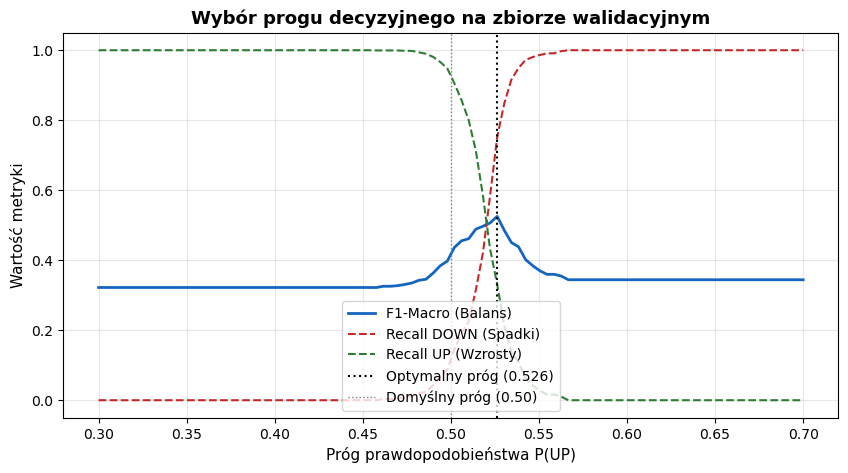


  PORÓWNANIE RAPORTÓW NA ZBIORZE TESTOWYM

1. DOMYŚLNY PRÓG (0.50):
              precision    recall  f1-score   support

        DOWN      0.714     0.103     0.180      1607
          UP      0.564     0.966     0.713      1935

    accuracy                          0.574      3542
   macro avg      0.639     0.534     0.446      3542
weighted avg      0.632     0.574     0.471      3542


2. ZOPTYMALIZOWANY PRÓG (0.5263):
              precision    recall  f1-score   support

        DOWN      0.487     0.704     0.576      1607
          UP      0.610     0.384     0.472      1935

    accuracy                          0.530      3542
   macro avg      0.549     0.544     0.524      3542
weighted avg      0.555     0.530     0.519      3542

Macierz pomyłek (Zoptymalizowany próg):
Rzeczywiste DOWN -> Błędnie UP: 475   | Poprawnie DOWN: 1132
Rzeczywiste UP   -> Poprawnie UP: 744   | Błędnie DOWN:  1191


In [80]:
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ── 1. Predykcje prawdopodobieństw na zbiorze WALIDACYJNYM i TESTOWYM ─────────
pred_proba_xgb_va = xgb_model.predict_proba(z_val_c)[:, 1]
pred_proba_xgb_te = xgb_model.predict_proba(z_test_c)[:, 1]

# ── 2. Przeszukiwanie siatki progów na zbiorze walidacyjnym ───────────────────
thresholds = np.linspace(0.30, 0.70, 100)
scores_macro_f1 = []
scores_bal_acc  = []
recalls_down    = []
recalls_up      = []

for th in thresholds:
    pred_va = (pred_proba_xgb_va >= th).astype(int)
    
    scores_macro_f1.append(f1_score(y_val_xgb, pred_va, average='macro'))
    scores_bal_acc.append(balanced_accuracy_score(y_val_xgb, pred_va))
    
    # Czułość dla obu klas
    r_down = np.mean(pred_va[y_val_xgb == 0] == 0) if np.sum(y_val_xgb == 0) > 0 else 0
    r_up   = np.mean(pred_va[y_val_xgb == 1] == 1) if np.sum(y_val_xgb == 1) > 0 else 0
    recalls_down.append(r_down)
    recalls_up.append(r_up)

# Wybór progu maksymalizującego F1-Macro (zrównoważenie obu klas)
best_idx = np.argmax(scores_macro_f1)
best_threshold = thresholds[best_idx]

print(f" Optymalny próg decyzyjny (wyznaczony na Val): {best_threshold:.4f}")
print(f"   Walidacja F1-Macro przy progu 0.50: {f1_score(y_val_xgb, (pred_proba_xgb_va >= 0.5).astype(int), average='macro'):.4f}")
print(f"   Walidacja F1-Macro przy progu {best_threshold:.2f}: {scores_macro_f1[best_idx]:.4f}")

# ── 3. Wizualizacja wpływu progu na metryki (Zbiór Walidacyjny) ────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, scores_macro_f1, label='F1-Macro (Balans)', color='#1565C0', lw=2)
ax.plot(thresholds, recalls_down,    label='Recall DOWN (Spadki)', color='#C62828', ls='--', lw=1.5)
ax.plot(thresholds, recalls_up,      label='Recall UP (Wzrosty)', color='#2E7D32', ls='--', lw=1.5)
ax.axvline(best_threshold, color='black', ls=':', lw=1.5, label=f'Optymalny próg ({best_threshold:.3f})')
ax.axvline(0.5, color='gray', ls=':', lw=1.0, label='Domyślny próg (0.50)')

ax.set_title('Wybór progu decyzyjnego na zbiorze walidacyjnym', fontweight='bold')
ax.set_xlabel('Próg prawdopodobieństwa P(UP)')
ax.set_ylabel('Wartość metryki')
ax.legend(loc='lower center')
ax.grid(True, alpha=0.3)
plt.show()

# ── 4. Ewaluacja na ZBIORZE TESTOWYM z nowym progiem ──────────────────────────
pred_class_default = (pred_proba_xgb_te >= 0.50).astype(int)
pred_class_optimal = (pred_proba_xgb_te >= best_threshold).astype(int)

print("\n" + "=" * 60)
print("  PORÓWNANIE RAPORTÓW NA ZBIORZE TESTOWYM")
print("=" * 60)

print("\n1. DOMYŚLNY PRÓG (0.50):")
print(classification_report(y_test_xgb, pred_class_default, target_names=['DOWN', 'UP'], digits=3))

print(f"\n2. ZOPTYMALIZOWANY PRÓG ({best_threshold:.4f}):")
print(classification_report(y_test_xgb, pred_class_optimal, target_names=['DOWN', 'UP'], digits=3))

# Macierz pomyłek dla nowego progu
cm = confusion_matrix(y_test_xgb, pred_class_optimal)
print("Macierz pomyłek (Zoptymalizowany próg):")
print(f"Rzeczywiste DOWN -> Błędnie UP: {cm[0, 1]:<5} | Poprawnie DOWN: {cm[0, 0]}")
print(f"Rzeczywiste UP   -> Poprawnie UP: {cm[1, 1]:<5} | Błędnie DOWN:  {cm[1, 0]}")

## 11. Przygotowanie danych dla agenta DQN

Stan DQN = `[z_t ‖ pred_proba_up ‖ position_t]`.

Prawdopodobieństwo wzrostu (`pred_proba_up`) zastępuje skalarną predykcję zwrotu — jest bardziej kalibrowane i mieści się w [0,1].

In [81]:
def xgb_predict_proba(z_arr):
    """Zwraca prawdopodobieństwo wzrostu ceny za HORIZON h."""
    return xgb_model.predict_proba(
        np.ascontiguousarray(z_arr, dtype=np.float32)
    )[:, 1]

pred_proba_train = xgb_predict_proba(z_train)
pred_proba_val   = xgb_predict_proba(z_val)
pred_proba_test  = xgb_predict_proba(z_test)

assert len(z_train) == len(pred_proba_train) == len(hourly_train), "Niezgodne wymiary!"
assert len(z_test)  == len(pred_proba_test)  == len(hourly_test),  "Niezgodne wymiary!"

print(f'DQN training samples : {len(z_train):,}')
print(f'DQN test samples     : {len(z_test):,}')
print(f'pred_proba (train) — mean={pred_proba_train.mean():.3f}  std={pred_proba_train.std():.3f}')
print(f'Hourly return (train) — mean={hourly_train.mean():.6f}  std={hourly_train.std():.4f}')

DQN training samples : 28,808
DQN test samples     : 3,542
pred_proba (train) — mean=0.518  std=0.017
Hourly return (train) — mean=0.000047  std=0.0054


In [83]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import xgboost as xgb

# ── 1. Przygotowanie cech wejściowych dla Regressora ─────────────────────────
# Stan = [Wektor LSTM (z_t) + Surowe wskaźniki + Prawdopodobieństwo P(UP)]
P_tr = pred_proba_train.reshape(-1, 1)
P_va = pred_proba_val.reshape(-1, 1)
P_te = pred_proba_test.reshape(-1, 1)

X_reg_train = np.ascontiguousarray(np.hstack([z_train, X_tr[:, -1, :], P_tr]), dtype=np.float32)
X_reg_val   = np.ascontiguousarray(np.hstack([z_val,   X_va[:, -1, :], P_va]), dtype=np.float32)
X_reg_test  = np.ascontiguousarray(np.hstack([z_test,  X_te[:, -1, :], P_te]), dtype=np.float32)

# Target: ciągły logarytmiczny zwrot za 72h
y_reg_train = train_df['target_return_7d_fwd'].values[WINDOW_LSTM:]
y_reg_val   = val_df['target_return_7d_fwd'].values[WINDOW_LSTM:]
y_reg_test  = test_df['target_return_7d_fwd'].values[WINDOW_LSTM:]

# ── 2. Trening XGBRegressor (z funkcją straty odporną na szum - Huber/MAE) ─────
reg_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.5,
    objective='reg:pseudohubererror',  # Odporność na ekstremalne świece (wicks)
    random_state=42,
    early_stopping_rounds=30,
    tree_method='hist'
)

print("Trenowanie regresora zwrotu...")
reg_model.fit(
    X_reg_train, y_reg_train,
    eval_set=[(X_reg_val, y_reg_val)],
    verbose=50
)
print(f"✓ Zakończono trening regresora (najlepsza iteracja: {reg_model.best_iteration})")

# ── 3. Rekonstrukcja ceny w USD na zbiorze testowym ───────────────────────────
pred_returns_te = reg_model.predict(X_reg_test)

# Aktualna cena Close w chwili t
current_close = test_last_close

# Przewidywana cena za 72h: Close_pred(t+72) = Close(t) * exp(pred_return)
pred_price_72h = current_close * np.exp(pred_returns_te)

# Rzeczywista cena, jaka wystąpiła 72h później
true_price_72h = current_close * np.exp(y_reg_test)

# ── 4. Metryki błędu kwotowego ────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(true_price_72h, pred_price_72h))
mae  = mean_absolute_error(true_price_72h, pred_price_72h)
mape = mean_absolute_percentage_error(true_price_72h, pred_price_72h) * 100

print("\n" + "=" * 50)
print("  EWALUACJA PREDYKCJI CENY (Horyzont +72h)")
print("=" * 50)
print(f"  RMSE: {rmse:.2f} USD")
print(f"  MAE:  {mae:.2f} USD")
print(f"  MAPE: {mape:.2f}%")
print("=" * 50)

Trenowanie regresora zwrotu...
[0]	validation_0-mphe:0.00034
[46]	validation_0-mphe:0.00034
✓ Zakończono trening regresora (najlepsza iteracja: 16)

  EWALUACJA PREDYKCJI CENY (Horyzont +72h)
  RMSE: 1672.68 USD
  MAE:  1137.00 USD
  MAPE: 1.64%


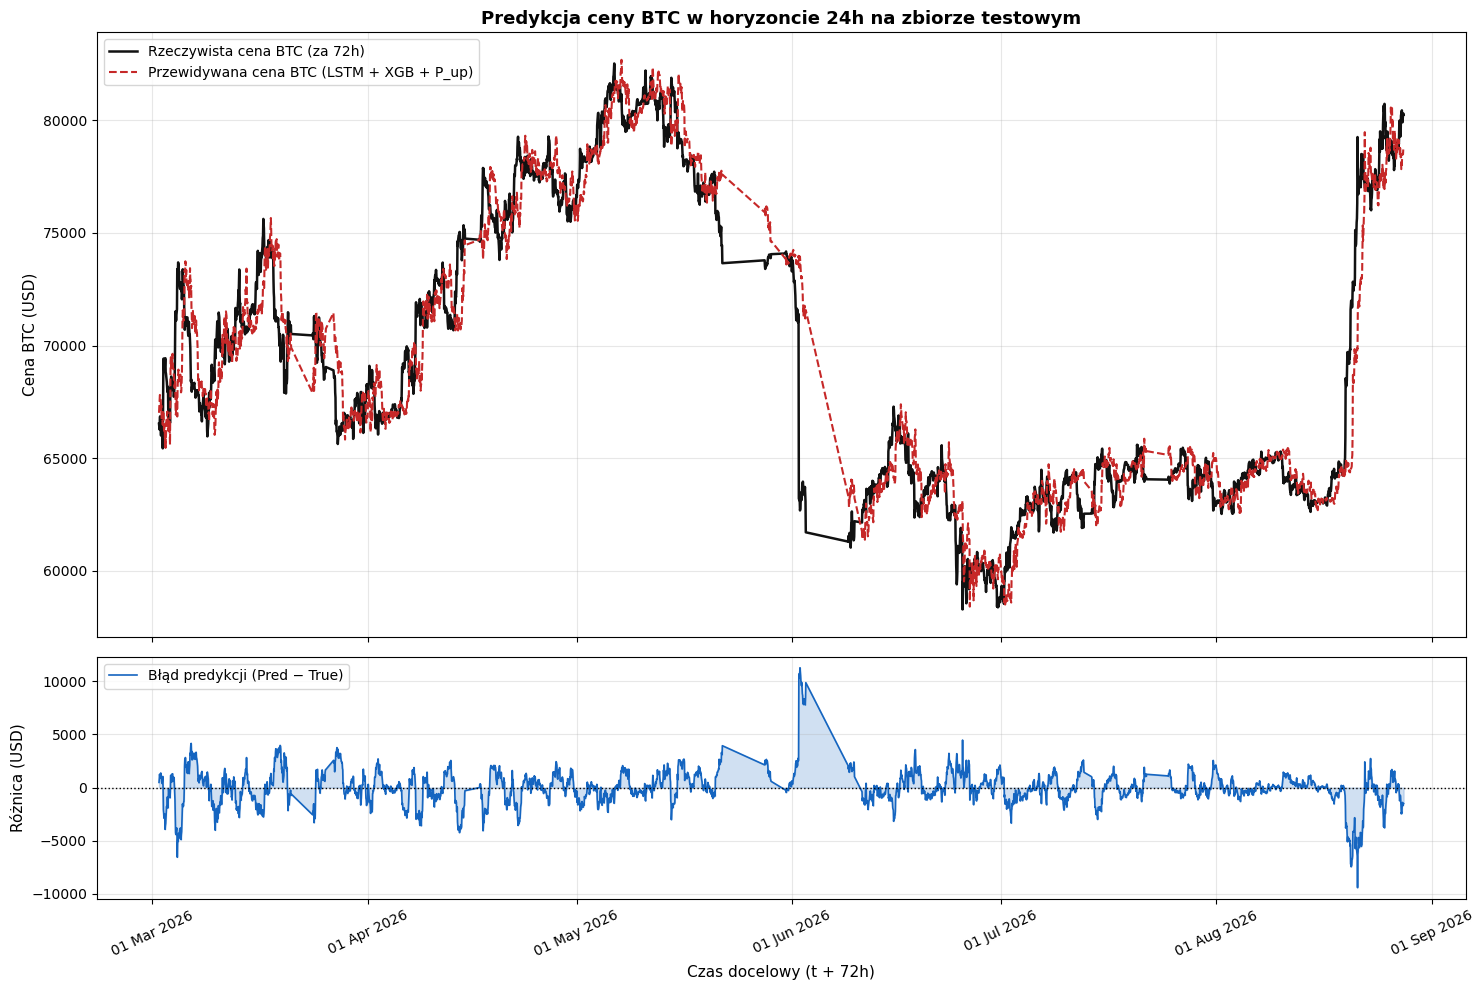

In [85]:
# Dopasowanie dat dla horyzontu t+72h
test_dates = test_df.index[WINDOW_LSTM:]
future_dates = test_dates + pd.Timedelta(hours=HORIZON)

# Podgląd fragmentu (np. pierwsze 400 godzin) lub całego zbioru: slice(None)
SLICE = slice(None)

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True, 
                         gridspec_kw={'height_ratios': [2.5, 1]})

# Panel 1: Przebieg ceny
ax = axes[0]
ax.plot(future_dates[SLICE], true_price_72h[SLICE], 
        color='#111111', lw=1.8, label='Rzeczywista cena BTC (za 72h)')
ax.plot(future_dates[SLICE], pred_price_72h[SLICE], 
        color='#C62828', lw=1.5, ls='--', label='Przewidywana cena BTC (LSTM + XGB + P_up)')
ax.set_title(f'Predykcja ceny BTC w horyzoncie {HORIZON}h na zbiorze testowym', fontweight='bold')
ax.set_ylabel('Cena BTC (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Panel 2: Błąd kwotowy w czasie (Residuals)
ax = axes[1]
error = pred_price_72h[SLICE] - true_price_72h[SLICE]
ax.plot(future_dates[SLICE], error, color='#1565C0', lw=1.2, label='Błąd predykcji (Pred − True)')
ax.axhline(0, color='black', ls=':', lw=1.0)
ax.fill_between(future_dates[SLICE], 0, error, color='#1565C0', alpha=0.2)
ax.set_ylabel('Różnica (USD)')
ax.set_xlabel('Czas docelowy (t + 72h)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 15. Ewaluacja na zbiorze testowym

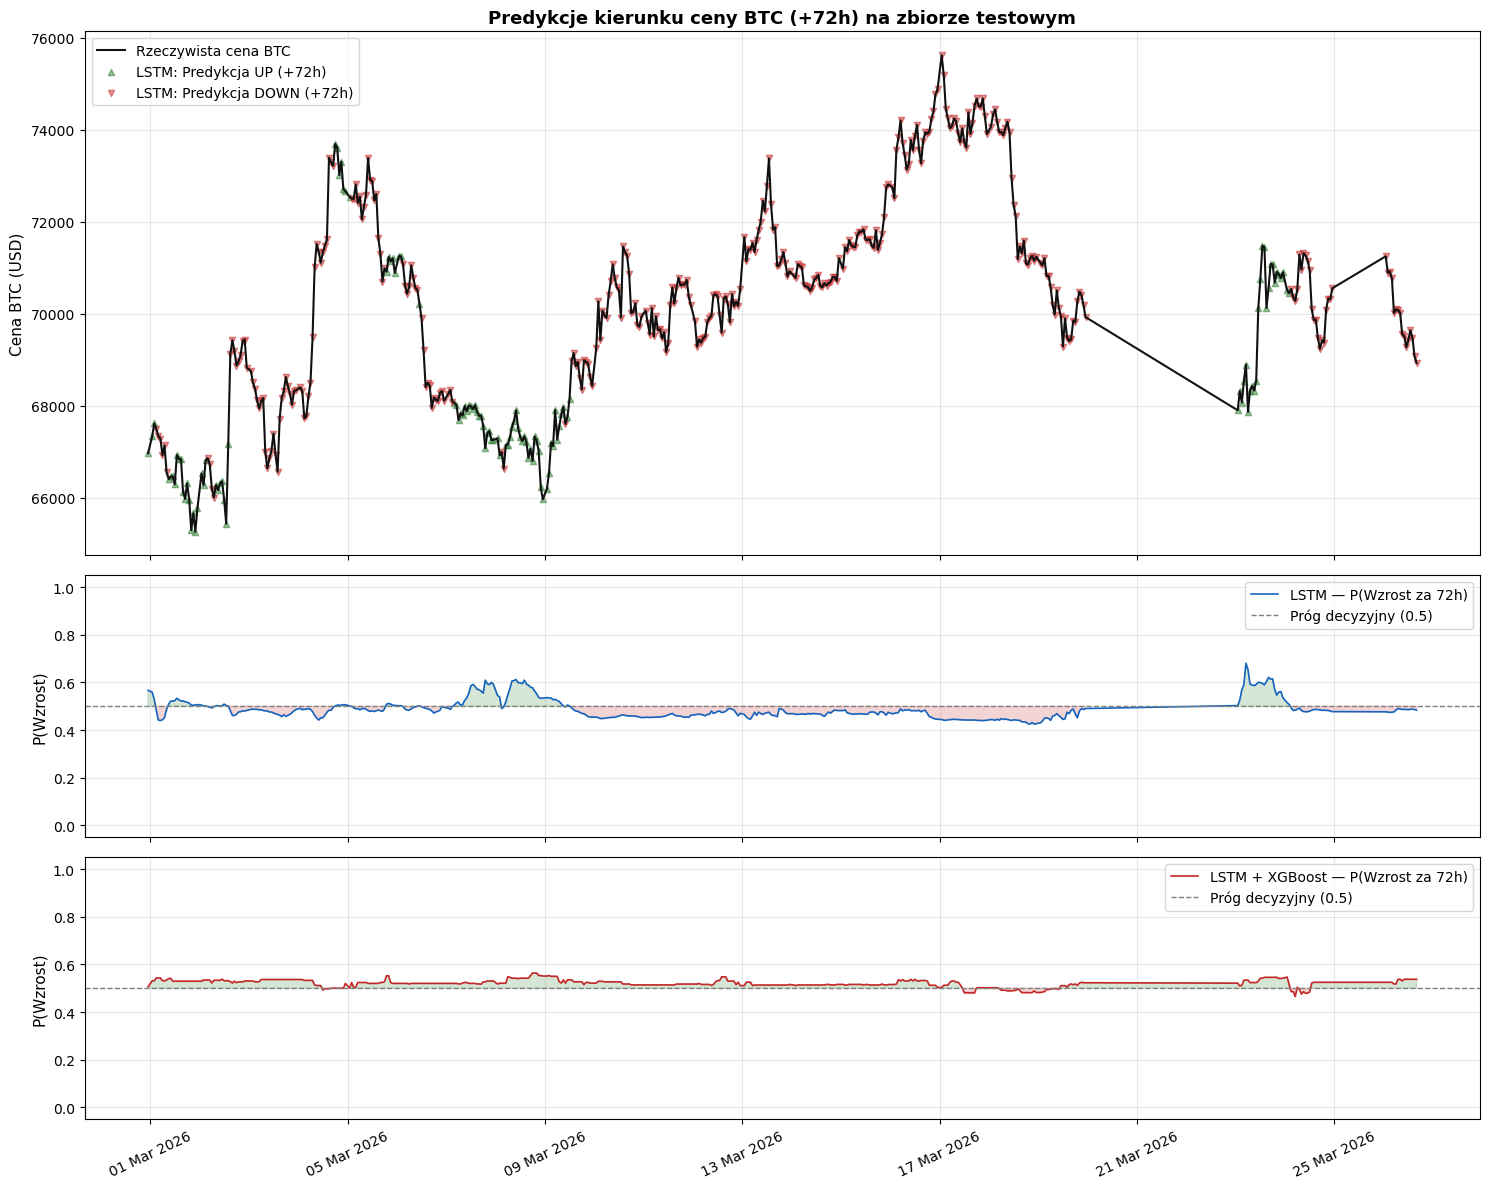

In [82]:
# ── Wizualizacja predykcji kierunku i prawdopodobieństw ───────────────────────
test_dates = test_df.index[WINDOW_LSTM:]
close_prices = test_last_close

# Opcjonalny zoom (np. pierwsze 500 godzin zbioru testowego dla lepszej czytelności)
# Zmień SLICE = slice(None) aby zobaczyć cały zbiór testowy
SLICE = slice(0, 500)

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True, 
                         gridspec_kw={'height_ratios': [2, 1, 1]})

# 1. Rzeczywista cena z predykcjami kierunku (LSTM vs LSTM+XGB)
ax = axes[0]
ax.plot(test_dates[SLICE], close_prices[SLICE], color=COLOR_TRUE, lw=1.5, label='Rzeczywista cena BTC')

# Sygnały LSTM (zielone/czerwone trójkąty)
lstm_up_mask = (pred_class_te[SLICE] == 1)
lstm_down_mask = (pred_class_te[SLICE] == 0)

ax.scatter(test_dates[SLICE][lstm_up_mask], close_prices[SLICE][lstm_up_mask], 
           color='#2E7D32', marker='^', alpha=0.5, s=20, label='LSTM: Predykcja UP (+72h)')
ax.scatter(test_dates[SLICE][lstm_down_mask], close_prices[SLICE][lstm_down_mask], 
           color='#C62828', marker='v', alpha=0.5, s=20, label='LSTM: Predykcja DOWN (+72h)')

ax.set_title('Predykcje kierunku ceny BTC (+72h) na zbiorze testowym', fontweight='bold')
ax.set_ylabel('Cena BTC (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# 2. Prawdopodobieństwo wzrostu — LSTM
ax = axes[1]
ax.plot(test_dates[SLICE], pred_proba_te[SLICE], color=COLOR_LSTM, lw=1.2, label='LSTM — P(Wzrost za 72h)')
ax.axhline(0.5, color='gray', ls='--', lw=1.0, label='Próg decyzyjny (0.5)')
ax.fill_between(test_dates[SLICE], 0.5, pred_proba_te[SLICE], 
                where=(pred_proba_te[SLICE] >= 0.5), color='#2E7D32', alpha=0.2)
ax.fill_between(test_dates[SLICE], 0.5, pred_proba_te[SLICE], 
                where=(pred_proba_te[SLICE] < 0.5), color='#C62828', alpha=0.2)
ax.set_ylabel('P(Wzrost)')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# 3. Prawdopodobieństwo wzrostu — LSTM + XGBoost
ax = axes[2]
ax.plot(test_dates[SLICE], pred_proba_xgb_te[SLICE], color=COLOR_HYBRID, lw=1.2, label='LSTM + XGBoost — P(Wzrost za 72h)')
ax.axhline(0.5, color='gray', ls='--', lw=1.0, label='Próg decyzyjny (0.5)')
ax.fill_between(test_dates[SLICE], 0.5, pred_proba_xgb_te[SLICE], 
                where=(pred_proba_xgb_te[SLICE] >= 0.5), color='#2E7D32', alpha=0.2)
ax.fill_between(test_dates[SLICE], 0.5, pred_proba_xgb_te[SLICE], 
                where=(pred_proba_xgb_te[SLICE] < 0.5), color='#C62828', alpha=0.2)
ax.set_ylabel('P(Wzrost)')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()